# **Proyecto 1:** Predicción de la calidad del vino tinto a partir de sus propiedades fisicoquímicas

|                 |                        |
:-----------------|------------------------|
| **Integrantes** | Omar Mendoza - 757806  |
|                 | Carlos Nieves - 758210 |
| **Fecha**       | 21/09/2026             |

Laboratorio de Aprendizaje Estadístico. Profesor: Gabriel Alejandro Morales Ruiz
---------

# Objetivos

## Objetivo general

Analizar qué propiedades fisicoquímicas del vino tinto Vinho Verde se asocian con la calidad que le asignan los catadores, construyendo y comparando modelos de regresión con y sin regularización, para identificar los factores significativos y evaluar qué tanto se puede predecir la calidad a partir de mediciones de laboratorio.

## Objetivos específicos

1. Describir el dataset Wine Quality (vino tinto): su origen, sus 11 variables fisicoquímicas y la variable de calidad, y detectar qué limpieza y transformaciones necesita antes de usarse en una regresión.
2. Proponer tres modelos de regresión distintos: uno con todos los factores, uno con interacción entre factores y uno polinomial.
3. Ajustar cada modelo en cuatro versiones: sin penalización, con Ridge, con Lasso y con Elastic Net, aplicando limpieza, transformación, escalamiento y partición train-test.
4. Analizar los residuos de cada modelo para revisar los seis problemas comunes de una regresión y hacer las transformaciones que salgan de ese análisis.
5. Comparar el desempeño de las doce versiones a través del R² en entrenamiento y en prueba.
6. Evaluar la significancia estadística de los factores en los modelos sin penalización para determinar cuáles propiedades tienen evidencia de afectar la calidad del vino.

# Marco teórico

## Regresión lineal

La regresión lineal modela la relación entre una variable dependiente $Y$ y una o más variables independientes $X_1, \dots, X_p$ suponiendo que esa relación es lineal en los parámetros:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$

donde $\beta_0$ es el intercepto, cada $\beta_j$ es el cambio esperado en $Y$ por cada unidad que sube $X_j$ manteniendo lo demás fijo, y $\epsilon$ es el error aleatorio. Los coeficientes se estiman por mínimos cuadrados ordinarios (OLS), que busca los valores de $\beta$ que minimizan la suma de residuos al cuadrado:

$$\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Qué tan bien ajusta el modelo se mide con el $R^2$, que es la proporción de la varianza de $Y$ que el modelo logra explicar. Va de 0 a 1 y entre más alto mejor, aunque siempre sube al agregar factores; por eso se compara también en datos de prueba que el modelo no vio.

## Regresión polinomial

Cuando la relación entre $X$ y $Y$ no es una recta sino una curva, se puede seguir usando regresión lineal agregando potencias de la variable como nuevos factores:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_d X^d + \epsilon$$

El modelo sigue siendo lineal en los parámetros, así que se ajusta igual con OLS. Lo que cambia es que ahora puede capturar curvatura. El riesgo es usar un grado muy alto, porque el polinomio empieza a seguir el ruido de los datos y pierde capacidad de generalizar (sobreajuste). En la práctica grados 2 o 3 suelen ser suficientes.

## Interacción de factores

Hay interacción cuando el efecto de un factor sobre $Y$ depende del nivel de otro factor. En un modelo aditivo cada $\beta_j$ es fijo, pero si se agrega el producto de dos variables:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 (X_1 \times X_2) + \epsilon$$

el efecto de $X_1$ pasa a ser $\beta_1 + \beta_3 X_2$, o sea que cambia según el valor de $X_2$. Si $\beta_3$ sale significativo hay evidencia de que los dos factores no actúan por separado. Por el principio de jerarquía, si se incluye la interacción también se dejan los efectos principales aunque no sean significativos.

## Significancia de factores

Para saber si un factor de verdad afecta a $Y$, o si su coeficiente pudo salir distinto de cero por azar, se hace una prueba de hipótesis por cada coeficiente:

$$H_0: \beta_j = 0 \qquad H_1: \beta_j \neq 0$$

El estadístico de prueba es $t = \hat{\beta}_j / SE(\hat{\beta}_j)$, que compara el tamaño del coeficiente contra su error estándar. De ahí sale el p-value, que es la probabilidad de ver un coeficiente así de grande si en realidad fuera cero. Si el p-value es menor al nivel de significancia $\alpha = 0.05$ se rechaza $H_0$ y se dice que el factor es significativo. Un factor significativo no necesariamente tiene un efecto grande, solo tiene un efecto que no parece ser cero.

## Regularización (Ridge, Lasso y Elastic Net)

La regularización agrega a la función de costo una penalización sobre el tamaño de los coeficientes. Con eso el modelo solo deja crecer un coeficiente si eso reduce el error lo suficiente, lo cual sacrifica un poco de sesgo pero reduce la varianza y ayuda a generalizar, sobre todo cuando hay muchos factores o están correlacionados entre sí.

**Ridge** usa penalización L2, la suma de los coeficientes al cuadrado:

$$\text{RSS}_{L2} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

Encoge los coeficientes hacia cero pero nunca los hace exactamente cero.

**Lasso** usa penalización L1, la suma de los valores absolutos:

$$\text{RSS}_{L1} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

Con L1 sí hay coeficientes que llegan a cero exacto, así que Lasso además selecciona variables.

**Elastic Net** combina las dos penalizaciones con un parámetro $\rho$ que reparte el peso entre L1 y L2:

$$\text{RSS}_{EN} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \left( \rho \sum_{j=1}^{p} |\beta_j| + (1 - \rho) \sum_{j=1}^{p} \beta_j^2 \right)$$

En los tres casos $\lambda$ (que en sklearn se llama `alpha`) controla qué tan fuerte es la penalización. Como la penalización depende del tamaño de los coeficientes, y ese tamaño depende de las unidades de cada factor, antes de regularizar se deben estandarizar las variables.

## Seis problemas comunes en una regresión

Los supuestos del modelo lineal se revisan con los residuos $e_i = y_i - \hat{y}_i$. Los seis problemas que se buscan son:

1. **No linealidad.** La relación real no es una recta. Se ve en la gráfica de residuos contra valores ajustados: si hay un patrón curvo el modelo lineal se queda corto.
2. **Correlación de los errores.** Los residuos no son independientes entre sí, típico en datos en el tiempo. Infla la confianza en los coeficientes.
3. **Varianza no constante.** El tamaño de los residuos cambia según el nivel del ajustado (heterocedasticidad). Se ve como un embudo en la gráfica de residuos.
4. **Valores atípicos.** Observaciones cuya $y$ queda muy lejos de lo que predice el modelo. Se detectan con residuos estandarizados mayores a 3 en valor absoluto.
5. **Puntos palanca.** Observaciones con valores raros en las $x$, que jalan la regresión más que las demás. Se miden con la palanca $h_i$, que se compara contra su promedio $(p+1)/n$.
6. **Colinealidad.** Dos o más factores traen casi la misma información, lo que infla los errores estándar y vuelve inestables los coeficientes. Se mide con el factor de inflación de varianza $\text{VIF}_j = 1/(1 - R^2_j)$; arriba de 5 o 10 ya es serio.

## Tema del proyecto: calidad del vino tinto

La calidad de un vino se decide en una cata sensorial, que es cara, lenta y subjetiva. Las propiedades fisicoquímicas en cambio se miden en laboratorio de forma objetiva y barata. La pregunta que se quiere responder es hasta dónde esas mediciones (acidez, azúcar, sulfitos, alcohol, pH, etc.) explican la calificación que dan los catadores. Los autores del dataset trabajaron este mismo problema con varios métodos de minería de datos; aquí se aborda con regresión lineal, sus extensiones y regularización, que es lo visto en el curso.

# Análisis del dataset

## ¿De dónde viene?

El dataset Wine Quality está en el UCI Machine Learning Repository, uno de los repositorios públicos de datasets más usados para investigación en aprendizaje automático. Fue creado en 2009 por Paulo Cortez de la Universidad de Minho junto con la Comisión de Viticultura de la Región de los Vinhos Verdes (CVRVV) en Portugal, para el artículo *Modeling wine preferences by data mining from physicochemical properties*. Hay dos archivos, uno de vino tinto y uno de vino blanco; en este proyecto se usa solo el tinto.

## ¿Qué contiene?

Son 1599 muestras de vino tinto Vinho Verde. Para cada una hay 11 variables fisicoquímicas medidas en laboratorio y una calificación de calidad de 0 a 10 que es la mediana de al menos tres catadores expertos. Por privacidad no hay marca, tipo de uva ni precio, solo lo que se midió.

| Variable | Qué es | Unidad |
|:---|:---|:---|
| fixed acidity | Acidez fija, principalmente ácido tartárico | g/dm³ |
| volatile acidity | Acidez volátil, ácido acético. Mucha da sabor a vinagre | g/dm³ |
| citric acid | Ácido cítrico, da frescura | g/dm³ |
| residual sugar | Azúcar que queda después de la fermentación | g/dm³ |
| chlorides | Sales, cloruro de sodio | g/dm³ |
| free sulfur dioxide | SO₂ libre, protege contra microbios y oxidación | mg/dm³ |
| total sulfur dioxide | SO₂ total, libre más ligado | mg/dm³ |
| density | Densidad, depende del alcohol y el azúcar | g/cm³ |
| pH | Qué tan ácido es, casi todos entre 3 y 4 | — |
| sulphates | Sulfatos, aditivo antimicrobiano | g/dm³ |
| alcohol | Grado alcohólico | % vol |
| **quality** | Calificación sensorial de los catadores | 0 a 10 |

## Librerías

In [1]:
# Librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Dataset

In [2]:
# Cargar el dataset, viene separado por punto y coma

datos = pd.read_csv("winequality-red.csv", sep=";")

print(datos.shape)
datos.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
datos.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


In [4]:
# Nulos y duplicados

print("Nulos:", datos.isna().sum().sum())
print("Duplicados:", datos.duplicated().sum())

Nulos: 0
Duplicados: 240


Son 1599 vinos con 11 variables quimicas y la calidad de 3 a 8. No hay nulos pero si 240 renglones repetidos que se van a quitar

## Análisis exploratorio de datos (EDA)

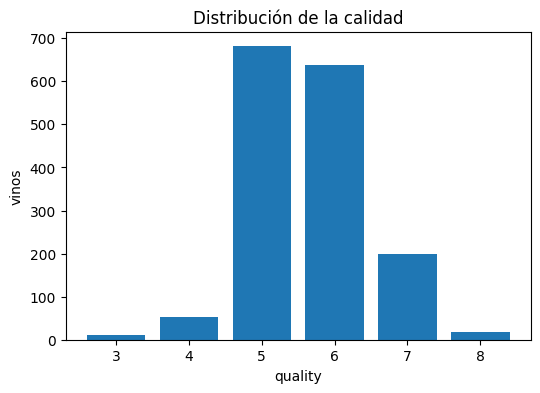

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [5]:
# Cómo se reparte la calidad

conteo = datos["quality"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(conteo.index, conteo.values)
plt.xlabel("quality")
plt.ylabel("vinos")
plt.title("Distribución de la calidad")
plt.show()

print(conteo)

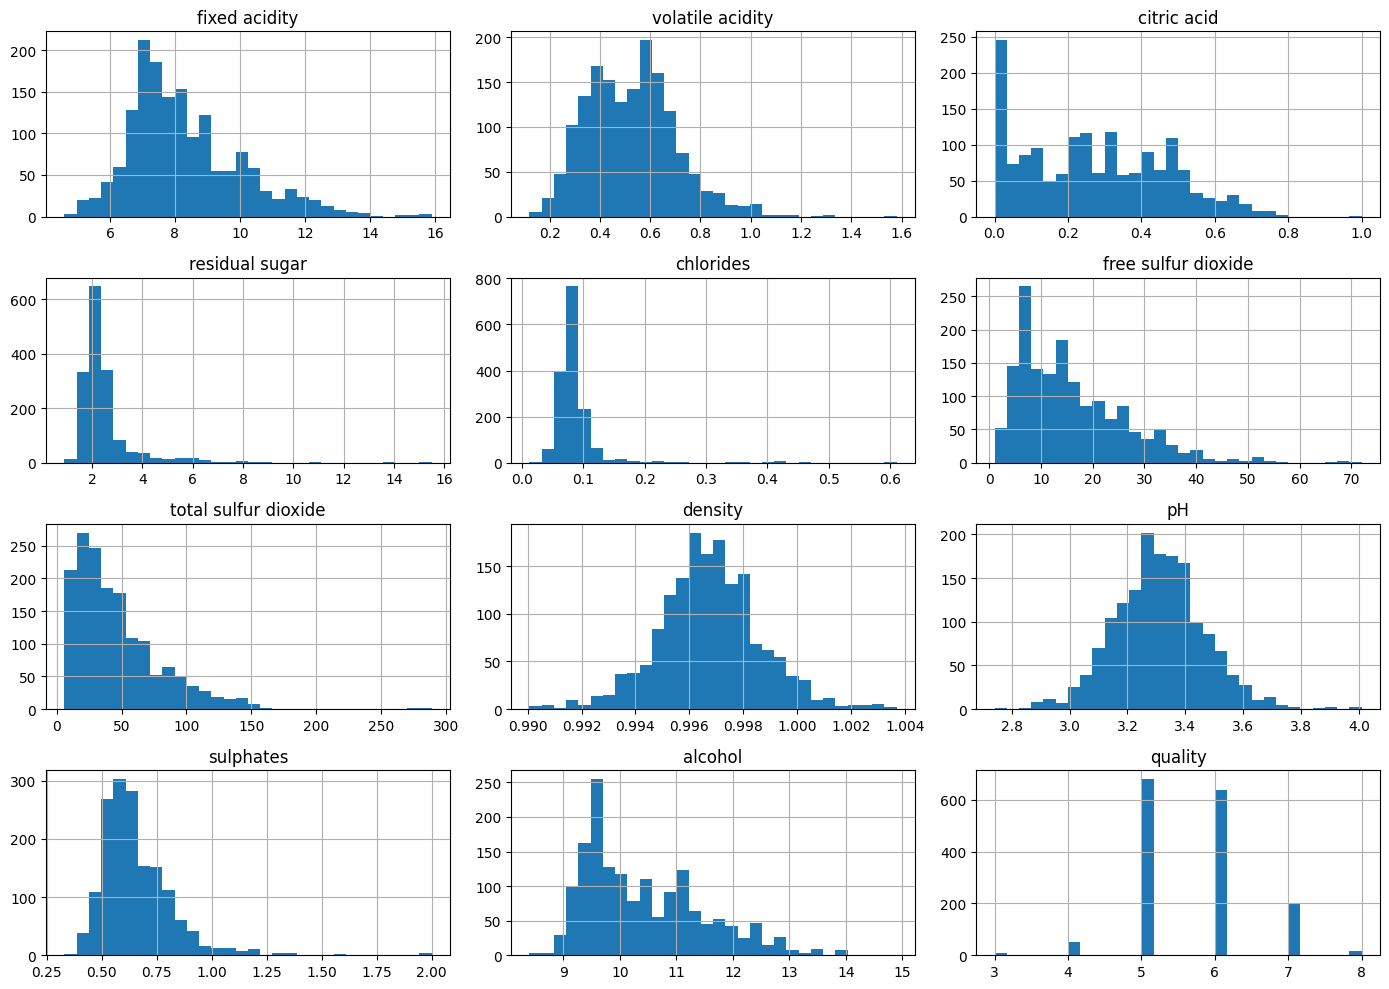

In [6]:
# Histograma de cada variable para ver su forma

datos.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [7]:
# Qué tan sesgada está cada variable

datos.drop(columns="quality").skew().sort_values(ascending=False).round(2)

chlorides               5.68
residual sugar          4.54
sulphates               2.43
total sulfur dioxide    1.52
free sulfur dioxide     1.25
fixed acidity           0.98
alcohol                 0.86
volatile acidity        0.67
citric acid             0.32
pH                      0.19
density                 0.07
dtype: float64

In [8]:
# Correlación de cada factor con la calidad

datos.corr()["quality"].drop("quality").sort_values(ascending=False).round(3)

alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64

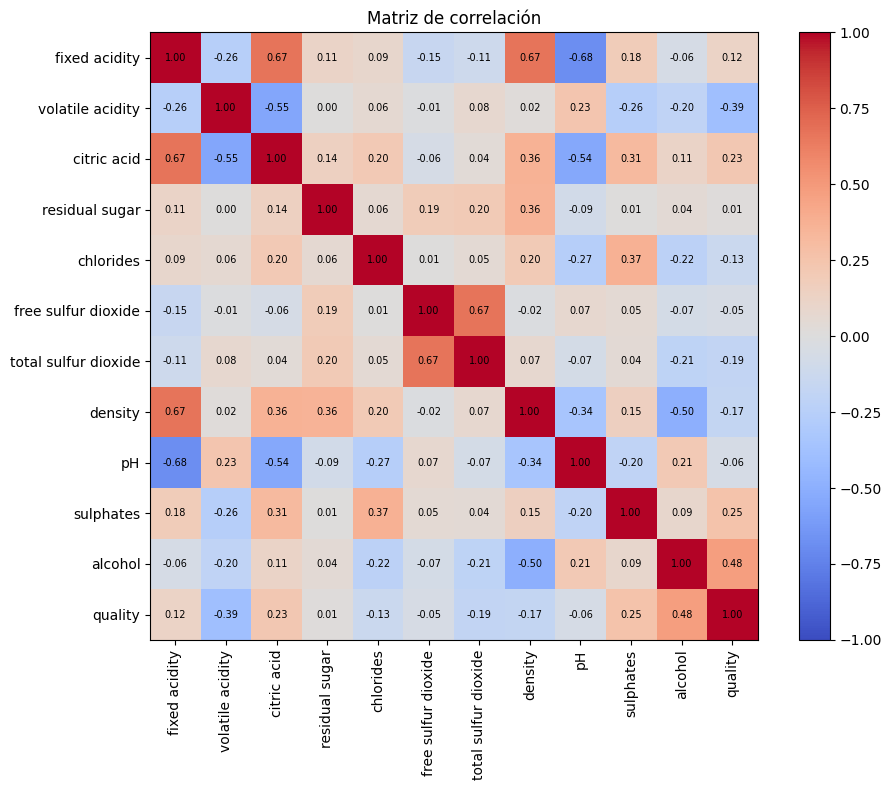

In [9]:
# Mapa de correlaciones entre todos los factores

corr = datos.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, "%.2f" % corr.iloc[i, j], ha="center", va="center", fontsize=7)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Casi todos los vinos son 5 o 6, hay muy pocos 3 y 8

alcohol es lo que mas se relaciona con la calidad (0.48) y volatile acidity lo que mas resta (-0.39). chlorides, residual sugar y sulphates tienen sesgo mayor a 2, con cola larga a la derecha

Entre factores hay pares muy correlacionados: fixed acidity con citric acid y con density (0.67), free con total sulfur dioxide (0.67), fixed acidity con pH (-0.68). Eso va a dar colinealidad

## ¿Qué información dan las muestras?

Cada renglón es un vino distinto con su análisis químico completo y su calificación. No hay orden en el tiempo ni relación entre renglones; cada muestra es independiente. Todas las variables son numéricas continuas menos `quality`, que es entera y en la práctica solo va de 3 a 8. La mayoría de los vinos están calificados con 5 o 6, hay muy pocos malos (3 y 4) y muy pocos excelentes (7 y 8), o sea que las clases están desbalanceadas.

## ¿Qué se quiere analizar?

Se quiere saber qué propiedades químicas se asocian con que un vino sea mejor o peor calificado, cuáles no aportan, si hay factores que interactúan entre sí o que tienen efecto curvo, y qué tanto se puede predecir la calidad con un modelo lineal. También se compara si regularizar ayuda o no.

La exploración inicial confirma lo esperado: `alcohol` es lo que más se relaciona con la calidad (correlación 0.48) y `volatile acidity` lo que más resta (−0.39). También aparecen pares muy correlacionados entre factores: `fixed acidity` con `citric acid` y con `density` (0.67), `free` con `total sulfur dioxide` (0.67), y `fixed acidity` contra `pH` (−0.68), lo que anticipa colinealidad.

## ¿Qué variables se tienen que transformar?

Todas las variables ya son numéricas, así que no hay que codificar categorías. Lo que sí necesita el dataset es:

- **Quitar duplicados.** Hay 240 renglones exactamente repetidos; son el mismo vino cargado dos veces y darían peso doble. Quedan 1359.
- **Transformación logarítmica** en las variables muy sesgadas a la derecha: `chlorides` (sesgo 5.5), `residual sugar` (4.55), `sulphates` (2.41), `total sulfur dioxide` (1.54) y `free sulfur dioxide` (1.23). Tienen colas largas que producen puntos palanca; el logaritmo las compacta. Ninguna tiene ceros (el mínimo de `chlorides` es 0.012), así que se aplica $\log(x)$ directo.
- **Estandarización** con `StandardScaler` ajustado solo en entrenamiento, porque las unidades son muy distintas (densidad ~0.99 contra sulfitos hasta 289) y la regularización lo necesita.
- **Partición** 70/30 en entrenamiento y prueba con semilla fija (42) para que sea reproducible.

## ¿Qué resultado se podría encontrar?

Por lo que se sabe del vino, se espera que el alcohol y los sulfatos se asocien positivamente con la calidad y que la acidez volátil (sabor a vinagre) se asocie negativamente. También se espera que el R² sea moderado, porque la calidad es una calificación subjetiva con solo seis valores posibles y la química no lo explica todo. Y como varias variables miden cosas parecidas (las dos acideces, los dos SO₂, densidad contra alcohol y azúcar), probablemente haya algo de colinealidad.

## Limpieza y transformación

In [10]:
# Limpieza: quitar los renglones duplicados

datos = datos.drop_duplicates().reset_index(drop=True)

print("Después de quitar duplicados:", datos.shape)

Después de quitar duplicados: (1359, 12)


In [11]:
# Funciones que se van a usar en todos los modelos

def por_tramos(x, valores, tramos=10):
    orden = np.argsort(x)
    grupos_x = np.array_split(x[orden], tramos)
    grupos_v = np.array_split(valores[orden], tramos)
    return [np.mean(g) for g in grupos_x], [np.mean(g) for g in grupos_v]


def vif(X):
    tabla = {}
    for col in X.columns:
        otras = [c for c in X.columns if c != col]
        r2 = LinearRegression().fit(X[otras], X[col]).score(X[otras], X[col])
        tabla[col] = 1 / (1 - r2)
    return pd.Series(tabla).sort_values(ascending=False)


def diagnostico(modelo, X, y, titulo):
    ajustados = modelo.fittedvalues.values
    residuos = modelo.resid.values
    n, p = X.shape[0], X.shape[1]

    rse = np.sqrt(np.sum(residuos ** 2) / (n - p - 1))
    estandarizados = residuos / rse

    Xc = sm.add_constant(X).values
    palanca = np.diag(Xc @ np.linalg.inv(Xc.T @ Xc) @ Xc.T)
    umbral = (p + 1) / n

    fig, ejes = plt.subplots(2, 2, figsize=(12, 8))

    cx, cy = por_tramos(ajustados, residuos)
    ejes[0, 0].scatter(ajustados, residuos, s=8, alpha=0.4)
    ejes[0, 0].plot(cx, cy, color="red", marker="o", linewidth=2)
    ejes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
    ejes[0, 0].set_title("1. No linealidad: residuos vs ajustados")
    ejes[0, 0].set_xlabel("ajustados"); ejes[0, 0].set_ylabel("residuos")

    cx2, cy2 = por_tramos(ajustados, np.abs(residuos))
    ejes[0, 1].scatter(ajustados, np.abs(residuos), s=8, alpha=0.4)
    ejes[0, 1].plot(cx2, cy2, color="red", marker="o", linewidth=2)
    ejes[0, 1].set_title("3. Varianza: |residuos| vs ajustados")
    ejes[0, 1].set_xlabel("ajustados"); ejes[0, 1].set_ylabel("|residuos|")

    atipicos = np.abs(estandarizados) > 3
    ejes[1, 0].scatter(ajustados[~atipicos], estandarizados[~atipicos], s=8, alpha=0.4)
    ejes[1, 0].scatter(ajustados[atipicos], estandarizados[atipicos], s=25, color="red")
    ejes[1, 0].axhline(3, color="gray", linestyle="--"); ejes[1, 0].axhline(-3, color="gray", linestyle="--")
    ejes[1, 0].set_title("4. Atípicos: residuos estandarizados (%d fuera de ±3)" % atipicos.sum())
    ejes[1, 0].set_xlabel("ajustados"); ejes[1, 0].set_ylabel("estandarizados")

    altos = palanca > umbral
    ejes[1, 1].scatter(palanca[~altos], estandarizados[~altos], s=8, alpha=0.4)
    ejes[1, 1].scatter(palanca[altos], estandarizados[altos], s=25, color="red")
    ejes[1, 1].axvline(umbral, color="gray", linestyle="--")
    ejes[1, 1].set_title("5. Palanca: %d arriba de (p+1)/n = %.4f" % (altos.sum(), umbral))
    ejes[1, 1].set_xlabel("palanca"); ejes[1, 1].set_ylabel("estandarizados")

    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

    corr_consec = np.corrcoef(residuos[:-1], residuos[1:])[0, 1]
    print("2. Correlación entre residuos consecutivos (orden del archivo): %.4f" % corr_consec)
    print("   Palanca máxima: %.4f  (promedio %.4f)" % (palanca.max(), umbral))
    print("6. VIF:")
    print(vif(X).round(2).to_string())


def prueba_hipotesis(modelo):
    tabla = pd.DataFrame({
        "coeficiente": modelo.params.round(4),
        "error estándar": modelo.bse.round(4),
        "t": modelo.tvalues.round(3),
        "p-value": modelo.pvalues.round(4),
    })
    tabla["significativo (α=0.05)"] = np.where(tabla["p-value"] < 0.05, "sí", "no")
    return tabla


def cuatro_versiones(X_train, X_test, y_train, y_test, alpha_ridge=1, alpha_lasso=0.01, alpha_enet=0.01):
    modelos = {
        "Sin penalización": LinearRegression(),
        "Ridge": Ridge(alpha=alpha_ridge),
        "Lasso": Lasso(alpha=alpha_lasso, max_iter=20000),
        "Elastic Net": ElasticNet(alpha=alpha_enet, l1_ratio=0.5, max_iter=20000),
    }
    filas, coefs = [], {}
    for nombre, m in modelos.items():
        m.fit(X_train, y_train)
        filas.append({"versión": nombre,
                      "R2 train": m.score(X_train, y_train),
                      "R2 test": m.score(X_test, y_test),
                      "coeficientes en 0": int((m.coef_ == 0).sum())})
        coefs[nombre] = pd.Series(m.coef_, index=X_train.columns)
    return pd.DataFrame(filas).set_index("versión"), pd.DataFrame(coefs)

Antes de transformar nada se ajusta el modelo con los datos crudos y se revisan sus residuos, para que la transformacion salga del analisis y no al azar

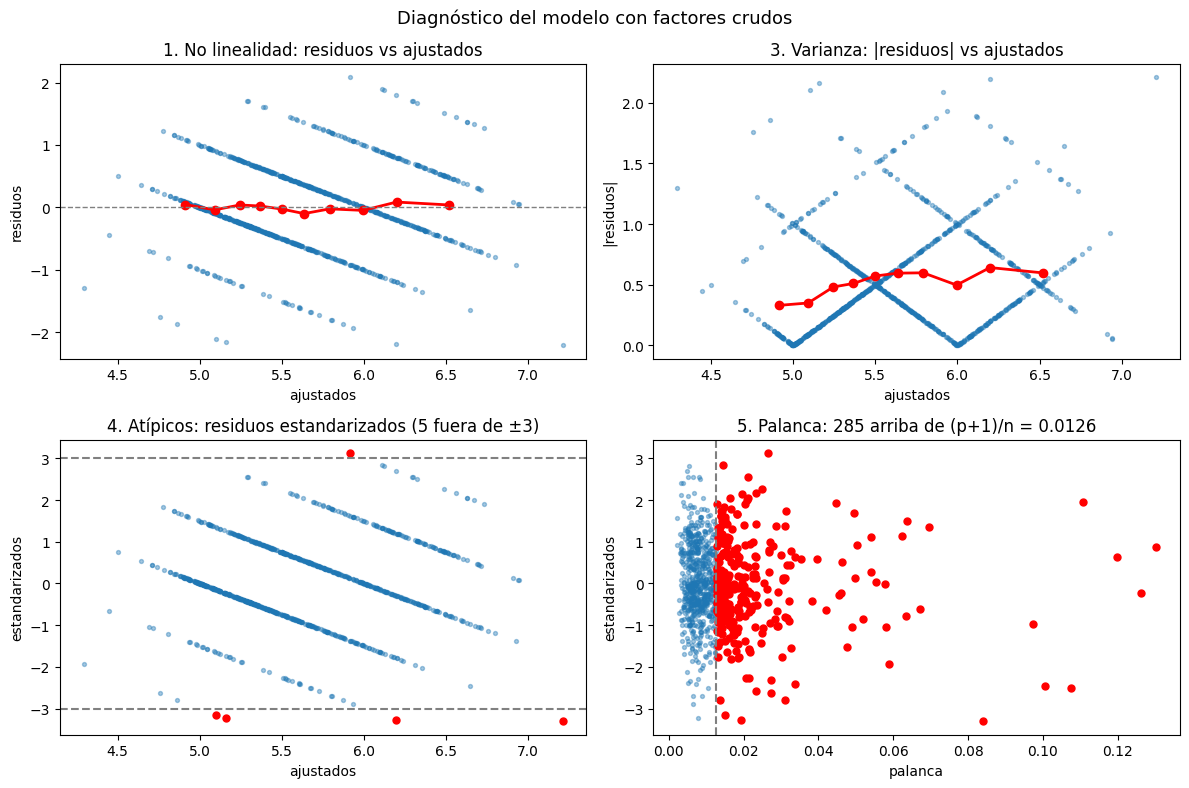

2. Correlación entre residuos consecutivos (orden del archivo): 0.0133
   Palanca máxima: 0.1303  (promedio 0.0126)
6. VIF:
fixed acidity           8.06
density                 6.12
pH                      3.47
alcohol                 3.25
citric acid             3.06
total sulfur dioxide    2.30
free sulfur dioxide     1.95
volatile acidity        1.76
residual sugar          1.56
chlorides               1.48
sulphates               1.42


In [12]:
# Modelo con todos los factores crudos, solo para diagnosticar

X_crudo = datos.drop(columns="quality")
y = datos["quality"]

X_train_c, X_test_c, y_train, y_test = train_test_split(X_crudo, y, test_size=0.3, random_state=42)

escalador_c = StandardScaler().fit(X_train_c)
X_train_c = pd.DataFrame(escalador_c.transform(X_train_c), columns=X_crudo.columns, index=X_train_c.index)

ols_crudo = sm.OLS(y_train, sm.add_constant(X_train_c)).fit()

diagnostico(ols_crudo, X_train_c, y_train, "Diagnóstico del modelo con factores crudos")

No hay curva en los residuos ni varianza que cambie mucho, las bandas diagonales son porque quality solo toma valores enteros

Lo que si sale es palanca alta en los vinos con chlorides, residual sugar o sulphates extremos, que son justo las variables sesgadas. Y fixed acidity y density con VIF arriba de 6

Por eso se les aplica logaritmo a las 5 variables sesgadas. Ninguna tiene ceros asi que se usa log directo

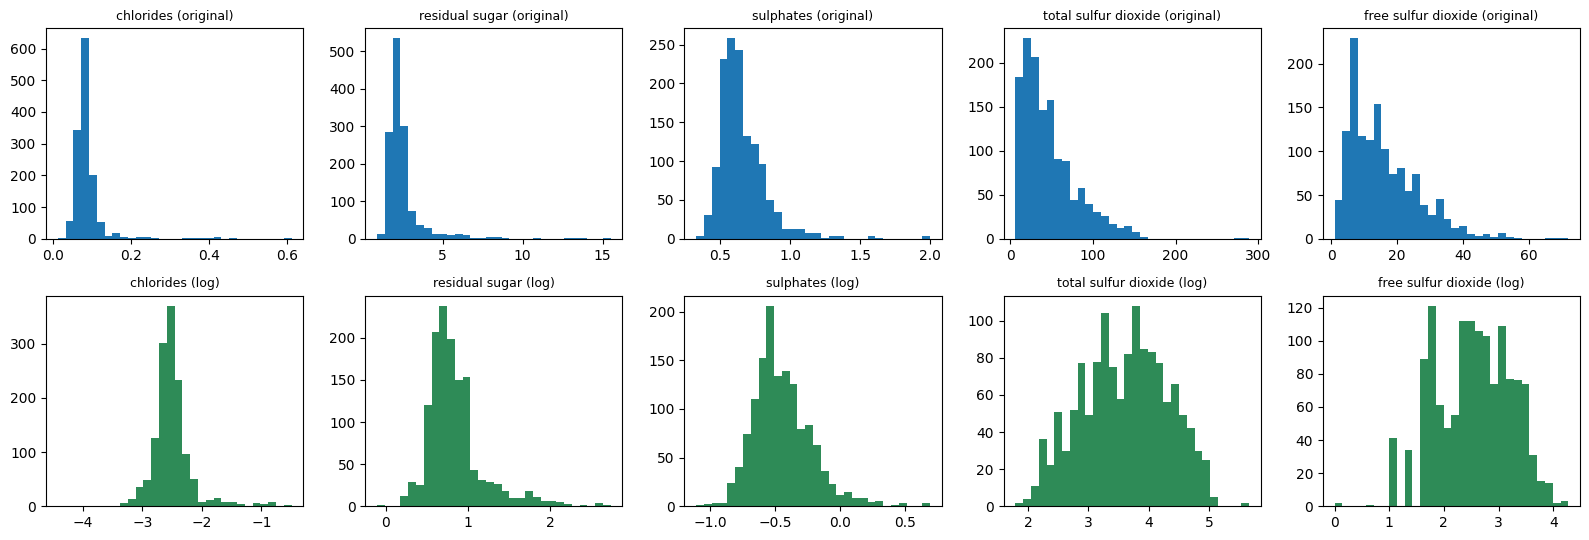

Sesgo antes:  {'chlorides': 5.5, 'residual sugar': 4.55, 'sulphates': 2.41, 'total sulfur dioxide': 1.54, 'free sulfur dioxide': 1.23}
Sesgo después: {'chlorides': 1.89, 'residual sugar': 1.77, 'sulphates': 0.96, 'total sulfur dioxide': -0.08, 'free sulfur dioxide': -0.22}


In [13]:
# Transformación logarítmica en las variables sesgadas

sesgadas = ["chlorides", "residual sugar", "sulphates", "total sulfur dioxide", "free sulfur dioxide"]

datos_t = datos.copy()
for col in sesgadas:
    datos_t[col] = np.log(datos_t[col])

fig, ejes = plt.subplots(2, 5, figsize=(16, 5.5))
for j, col in enumerate(sesgadas):
    ejes[0, j].hist(datos[col], bins=30)
    ejes[0, j].set_title(col + " (original)", fontsize=9)
    ejes[1, j].hist(datos_t[col], bins=30, color="seagreen")
    ejes[1, j].set_title(col + " (log)", fontsize=9)
plt.tight_layout()
plt.show()

print("Sesgo antes: ", datos[sesgadas].skew().round(2).to_dict())
print("Sesgo después:", datos_t[sesgadas].skew().round(2).to_dict())

El sesgo baja en las cinco, total y free sulfur dioxide quedan casi simetricas y chlorides y residual sugar bajan de 5.5 y 4.5 a menos de 2

# Modelo propuesto

Se definen tres modelos distintos para comparar entre ellos. Cada uno se ajusta en cuatro versiones: sin penalización (OLS), con Ridge (`alpha` = 1), con Lasso (`alpha` = 0.01) y con Elastic Net (`alpha` = 0.01, $\rho$ = 0.5). Los alphas se eligen con un barrido sobre el modelo 1 mirando el R² de prueba; se usan los mismos en los tres modelos para que la comparación sea justa.

## Transformaciones a partir del análisis de residuos

Antes de transformar nada se ajustó el modelo con los 11 factores tal cual vienen y se revisaron sus residuos. El diagnóstico del modelo crudo mostró:

- **No linealidad:** sin patrón curvo. Las bandas diagonales que se ven no son un problema del modelo, son porque `quality` solo toma valores enteros.
- **Varianza:** pareja en el centro, un poco mayor en los extremos por el mismo motivo.
- **Atípicos:** algunos vinos con residuo estandarizado fuera de ±3, casi todos calificados con 3 u 8.
- **Puntos palanca:** varios puntos muy separados a la derecha, palanca máxima 0.13 contra un promedio de 0.0126. Son los vinos con valores extremos en `chlorides`, `residual sugar` o `sulphates`, justo las variables con sesgo mayor a 2. Esto es lo que motivó la transformación logarítmica.
- **Colinealidad:** `fixed acidity` (VIF 8.06) y `density` (6.12) por su relación con `citric acid`, `pH` y `alcohol`.
- **Correlación de errores:** prácticamente cero, como se espera de muestras independientes.

Con base en eso se aplica $\log(x)$ a las cinco variables sesgadas. El sesgo baja en todas: `total` y `free sulfur dioxide` quedan casi simétricas (−0.08 y −0.22), `sulphates` baja de 2.41 a 0.96, y `chlorides` y `residual sugar` bajan de 5.5 y 4.55 a 1.89 y 1.77. Con eso la palanca máxima del modelo 1 cae de 0.13 a 0.078.

## Modelo 1: todos los factores

Es el modelo base, con los 11 factores sin interacciones ni polinomios.

$$\text{quality} = \beta_0 + \beta_1(\text{fixed acidity}) + \beta_2(\text{volatile acidity}) + \beta_3(\text{citric acid}) + \beta_4(\log \text{residual sugar}) + \beta_5(\log \text{chlorides}) + \beta_6(\log \text{free SO}_2) + \beta_7(\log \text{total SO}_2) + \beta_8(\text{density}) + \beta_9(\text{pH}) + \beta_{10}(\log \text{sulphates}) + \beta_{11}(\text{alcohol}) + \epsilon$$

Su diagnóstico de residuos (ya con las variables transformadas) deja `fixed acidity` y `density` con VIF de 8.10 y 7.25, arriba del umbral de 5. Por eso esos dos factores se excluyen de los modelos 2 y 3.

## Modelo 2: factores significativos con interacción

Se toman solo los seis factores que resultan significativos en el modelo 1 y no tienen VIF alto, y se agrega la interacción entre `alcohol` y `sulphates`. La idea es que el efecto del alcohol sobre la calidad puede depender del nivel de sulfatos, que es un conservador que afecta cómo se percibe el vino. Se probaron seis interacciones candidatas sobre el modelo 1 y esta fue la única significativa (p = 0.0023).

$$\text{quality} = \beta_0 + \beta_1(\text{alcohol}) + \beta_2(\text{volatile acidity}) + \beta_3(\log \text{sulphates}) + \beta_4(\log \text{total SO}_2) + \beta_5(\log \text{chlorides}) + \beta_6(\text{pH}) + \beta_7(\text{alcohol} \times \log \text{sulphates}) + \epsilon$$

En su diagnóstico todos los VIF quedan entre 1.10 y 1.40; la colinealidad desaparece. Como las variables se estandarizan antes de multiplicarse, la interacción no infla el VIF de sus componentes.

## Modelo 3: polinomial

Se toman los tres factores más fuertes y se agregan los términos cuadráticos de `alcohol` y `sulphates`, que son los que muestran curvatura significativa al probarlos por separado (p del término cuadrático: 0.0018 y < 0.0001). Se conserva `volatile acidity` lineal.

$$\text{quality} = \beta_0 + \beta_1(\text{alcohol}) + \beta_2(\text{alcohol})^2 + \beta_3(\log \text{sulphates}) + \beta_4(\log \text{sulphates})^2 + \beta_5(\text{volatile acidity}) + \epsilon$$

Los VIF entre los términos cuadráticos y sus lineales suben un poco, lo normal en un polinomio, pero se mantienen abajo de 2. La palanca muestra los vinos con alcohol o sulfatos extremos, que al elevarse al cuadrado se separan más.

# Pipeline

El flujo completo del proyecto sigue el esquema visto en clase: del dataset se hace el EDA, de ahí salen $X$ y $y$, $X$ pasa por la ingeniería de características para obtener $X^*$, con $X^*$ y $y$ se ajusta la regresión (con su `alpha` cuando hay penalización) y se obtiene el modelo entrenado. Con el modelo se predice $\hat{y}$, se calculan los residuos $\varepsilon = y - \hat{y}$ para el análisis de residuos, y se revisa la significancia estadística de los coeficientes. Los datos nuevos ($X_{new}$, que aquí es el conjunto de prueba) pasan por la misma ingeniería de características ya ajustada antes de predecir. Todo lo que va de la ingeniería de características al ajuste es el pipeline del proyecto.

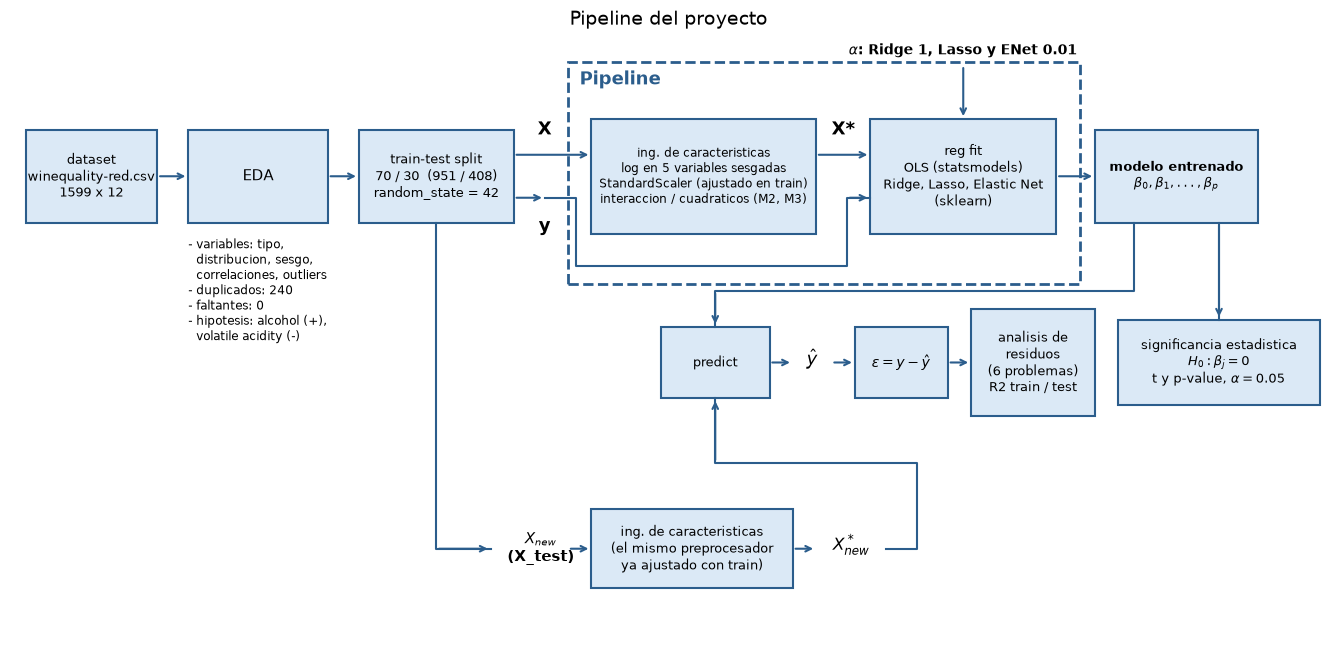

Paso por paso, adaptado a este proyecto:

1. **Dataset.** Se lee `winequality-red.csv` (separado por punto y coma): 1599 renglones y 12 columnas.
2. **EDA.** Se revisan el tipo y la distribución de cada variable, el sesgo, las correlaciones y los valores extremos; se detectan 240 duplicados (se eliminan, quedan 1359) y 0 faltantes; se plantea la hipótesis de que el alcohol suma y la acidez volátil resta.
3. **Transformación.** Se aplica $\log(x)$ a `chlorides`, `residual sugar`, `sulphates`, `total sulfur dioxide` y `free sulfur dioxide`. Es una transformación fija que no aprende nada de los datos, por eso se hace antes de partir.
4. **X, y y train-test split.** `X` son los 11 factores y `y` es `quality`. Se parte 70 % entrenamiento (951 vinos) y 30 % prueba (408) con `random_state = 42`.
5. **Escalamiento.** `StandardScaler` ajustado solo con el conjunto de entrenamiento y aplicado al de prueba con esas mismas medias y desviaciones, para que la información del test no se filtre al modelo.
6. **Construcción de $X^*$.** Sobre las variables ya escaladas se arman las tres matrices: todas las columnas (M1), subconjunto más la columna de interacción (M2) y subconjunto más las columnas al cuadrado (M3).
7. **Ajuste.** Para cada $X^*$ se ajustan OLS (statsmodels, con columna de unos), Ridge (`alpha` = 1), Lasso y Elastic Net (sklearn, `alpha` = 0.01).
8. **Modelo entrenado → significancia estadística.** Con el OLS se prueba $H_0: \beta_j = 0$ por factor con $\alpha = 0.05$.
9. **Predict → $\hat{y}$ → residuos.** Se predice en entrenamiento y en prueba, se calcula el R² de cada uno, y con los residuos de entrenamiento se hace el análisis de los seis problemas (no linealidad, correlación de errores, varianza, atípicos, palanca y VIF).
10. **Datos nuevos.** El conjunto de prueba pasa por el mismo escalador ya ajustado y por la misma construcción de $X^*$ antes de predecir.

## Separar el dataset en train y test y estandarizar

In [14]:
# Partición 70/30 y escalamiento ajustado solo en entrenamiento

X_todo = datos_t.drop(columns="quality")
y = datos_t["quality"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_todo, y, test_size=0.3, random_state=42)

escalador = StandardScaler().fit(X_train_raw)

X_train_all = pd.DataFrame(escalador.transform(X_train_raw), columns=X_todo.columns, index=X_train_raw.index)
X_test_all = pd.DataFrame(escalador.transform(X_test_raw), columns=X_todo.columns, index=X_test_raw.index)

print("Entrenamiento:", X_train_all.shape)
print("Prueba:", X_test_all.shape)

Entrenamiento: (951, 11)
Prueba: (408, 11)


El escalador se ajusta solo con train y se aplica a test con esas mismas medias, para que no se filtre informacion del test

## Elección de alpha

In [15]:
# Barrido de alpha para las tres penalizaciones

filas = []
for a in [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 100]:
    r = Ridge(alpha=a).fit(X_train_all, y_train)
    l = Lasso(alpha=a, max_iter=20000).fit(X_train_all, y_train)
    e = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=20000).fit(X_train_all, y_train)
    filas.append({"alpha": a,
                  "Ridge R2 test": r.score(X_test_all, y_test),
                  "Lasso R2 test": l.score(X_test_all, y_test), "Lasso ceros": int((l.coef_ == 0).sum()),
                  "ENet R2 test": e.score(X_test_all, y_test), "ENet ceros": int((e.coef_ == 0).sum())})

pd.DataFrame(filas).set_index("alpha").round(4)

,Ridge R2 test,Lasso R2 test,Lasso ceros,ENet R2 test,ENet ceros
alpha,,,,,
0.001,0.3921,0.3947,0,0.3935,0
0.010,0.3921,0.3982,3,0.3963,2
0.050,0.3921,0.3876,5,0.3962,5
0.100,0.3921,0.3537,8,0.3831,5
0.500,0.3922,-0.0000,11,0.1464,9
1.000,0.3923,-0.0000,11,-0.0000,11
10.000,0.3939,-0.0000,11,-0.0000,11
100.000,0.3943,-0.0000,11,-0.0000,11


Ridge casi no cambia con alpha porque los factores ya estan estandarizados. Lasso y Elastic Net se apagan rapido, Lasso con 0.5 ya no deja nada

El mejor R2 de test sale con alpha 0.01, ahi Lasso quita 3 factores sin perder ajuste. Se usa alpha 1 para Ridge y 0.01 para Lasso y Elastic Net en los tres modelos

# **MODELO 1**

Todos los factores

$$\text{quality} = \beta_0 + \beta_1(\text{fixed acidity}) + \beta_2(\text{volatile acidity}) + \beta_3(\text{citric acid}) + \beta_4(\log \text{residual sugar}) + \beta_5(\log \text{chlorides}) + \beta_6(\log \text{free SO}_2) + \beta_7(\log \text{total SO}_2) + \beta_8(\text{density}) + \beta_9(\text{pH}) + \beta_{10}(\log \text{sulphates}) + \beta_{11}(\text{alcohol})$$

In [16]:
X_train1, X_test1 = X_train_all.copy(), X_test_all.copy()

## Regresión sin penalización

In [17]:
ols1 = sm.OLS(y_train, sm.add_constant(X_train1)).fit()

print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     47.64
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           7.85e-83
Time:                        22:15:18   Log-Likelihood:                -953.92
No. Observations:                 951   AIC:                             1932.
Df Residuals:                     939   BIC:                             1990.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6246 

## Prueba de hipótesis

Para cada variable se evalúa:

$$
H_0: \beta_i = 0 \\
H_1: \beta_i \neq 0
$$
$$
\text{con un nivel de significancia de } \alpha = 0.05$$

In [18]:
prueba_hipotesis(ols1)

,coeficiente,error estándar,t,p-value,significativo (α=0.05)
const,5.6246,0.0215,261.237,0.0000,sí
fixed acidity,-0.0312,0.0613,-0.508,0.6112,no
volatile acidity,-0.1670,0.0286,-5.849,0.0000,sí
citric acid,-0.0208,0.0368,-0.565,0.5720,no
residual sugar,-0.0212,0.0287,-0.738,0.4610,no
chlorides,-0.1014,0.0261,-3.884,0.0001,sí
free sulfur dioxide,0.0936,0.0370,2.527,0.0117,sí
total sulfur dioxide,-0.1262,0.0392,-3.219,0.0013,sí
density,0.0425,0.0580,0.733,0.4635,no
pH,-0.1217,0.0399,-3.049,0.0024,sí


Siete factores rechazan H0: volatile acidity, sulphates, alcohol, total sulfur dioxide, chlorides, pH y free sulfur dioxide

Los otros cuatro (fixed acidity, citric acid, residual sugar y density) no son significativos. fixed acidity y density son justo los de VIF mas alto, su informacion ya la traen otros

Los coeficientes mas grandes son alcohol (+), sulphates (+) y volatile acidity (-), como se esperaba

## Análisis de residuos

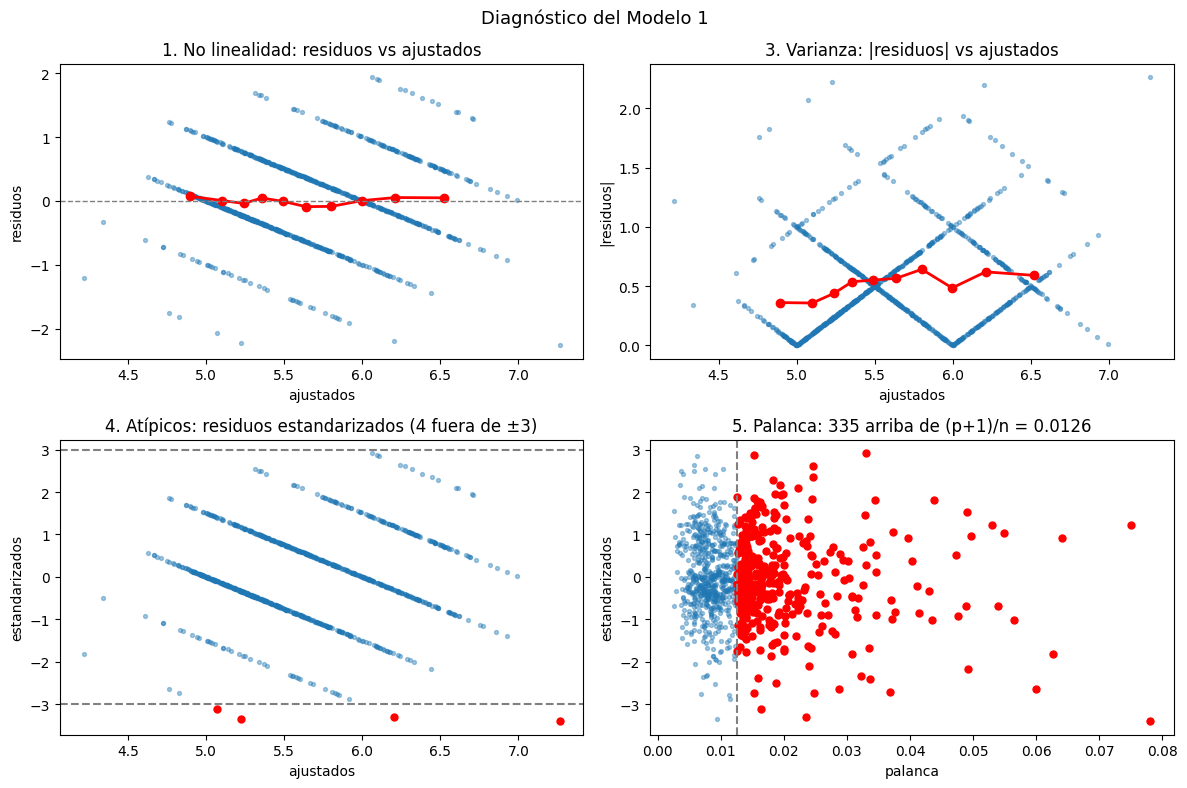

2. Correlación entre residuos consecutivos (orden del archivo): 0.0173
   Palanca máxima: 0.0780  (promedio 0.0126)
6. VIF:
fixed acidity           8.10
density                 7.25
alcohol                 3.68
pH                      3.44
total sulfur dioxide    3.32
free sulfur dioxide     2.96
citric acid             2.92
residual sugar          1.78
volatile acidity        1.76
chlorides               1.47
sulphates               1.42


In [19]:
diagnostico(ols1, X_train1, y_train, "Diagnóstico del Modelo 1")

Con el log la palanca maxima bajo de 0.13 a 0.078, ya no hay puntos tan apartados

fixed acidity y density siguen con VIF arriba de 5, por eso en los modelos 2 y 3 se quedan fuera

## Ridge, Lasso y Elastic Net

In [20]:
tabla1, coefs1 = cuatro_versiones(X_train1, X_test1, y_train, y_test)

tabla1.round(4)

,R2 train,R2 test,coeficientes en 0
versión,,,
Sin penalización,0.3582,0.3921,0
Ridge,0.3582,0.3923,0
Lasso,0.3554,0.3982,3
Elastic Net,0.3570,0.3963,2


In [21]:
coefs1.round(4)

,Sin penalización,Ridge,Lasso,Elastic Net
fixed acidity,-0.0312,-0.0289,0.0000,0.0000
volatile acidity,-0.1670,-0.1669,-0.1597,-0.1587
citric acid,-0.0208,-0.0206,-0.0000,-0.0012
residual sugar,-0.0212,-0.0205,-0.0030,-0.0067
chlorides,-0.1014,-0.1012,-0.0878,-0.0937
free sulfur dioxide,0.0936,0.0930,0.0457,0.0679
total sulfur dioxide,-0.1262,-0.1256,-0.0804,-0.1021
density,0.0425,0.0402,-0.0000,0.0000
pH,-0.1217,-0.1203,-0.0807,-0.0898
sulphates,0.1768,0.1769,0.1700,0.1745


Ridge deja todo casi igual. Lasso apaga fixed acidity, citric acid y density, tres de los cuatro que no eran significativos. Elastic Net apaga dos

El R2 de test sube un poco con Lasso porque quitar factores que sobran baja la varianza

# **MODELO 2**

Solo los factores significativos sin VIF alto, mas la interaccion de alcohol con sulphates

$$\text{quality} = \beta_0 + \beta_1(\text{alcohol}) + \beta_2(\text{volatile acidity}) + \beta_3(\log \text{sulphates}) + \beta_4(\log \text{total SO}_2) + \beta_5(\log \text{chlorides}) + \beta_6(\text{pH}) + \beta_7(\text{alcohol} \times \log \text{sulphates})$$

In [22]:
# Se probaron varias interacciones sobre el modelo 1, esta es la única que sale significativa

pares = [("alcohol", "sulphates"), ("alcohol", "volatile acidity"), ("volatile acidity", "sulphates"),
         ("alcohol", "pH"), ("alcohol", "total sulfur dioxide"), ("sulphates", "chlorides")]

for a, b in pares:
    Xi = X_train_all.copy()
    Xi[a + " x " + b] = Xi[a] * Xi[b]
    mi = sm.OLS(y_train, sm.add_constant(Xi)).fit()
    print("%-18s x %-22s p = %.4f   R2 = %.4f" % (a, b, mi.pvalues.iloc[-1], mi.rsquared))

alcohol            x sulphates              p = 0.0023   R2 = 0.3645
alcohol            x volatile acidity       p = 0.5117   R2 = 0.3585
volatile acidity   x sulphates              p = 0.5048   R2 = 0.3585
alcohol            x pH                     p = 0.2668   R2 = 0.3590
alcohol            x total sulfur dioxide   p = 0.8705   R2 = 0.3582
sulphates          x chlorides              p = 0.0573   R2 = 0.3607


## Definir la matriz X para el segundo modelo

In [23]:
factores2 = ["alcohol", "volatile acidity", "sulphates", "total sulfur dioxide", "chlorides", "pH"]

X_train2 = X_train_all[factores2].copy()
X_test2 = X_test_all[factores2].copy()

X_train2["alcohol x sulphates"] = X_train2["alcohol"] * X_train2["sulphates"]
X_test2["alcohol x sulphates"] = X_test2["alcohol"] * X_test2["sulphates"]

X_train2.head()

,alcohol,volatile acidity,sulphates,total sulfur dioxide,chlorides,pH,alcohol x sulphates
328,0.352420,-0.670106,1.058306,0.348711,0.235650,-1.999857,0.372968
1043,-0.939819,-0.387402,-1.007593,1.036109,0.301207,-1.062681,0.946955
318,-0.201397,-0.387402,1.377414,-1.241613,-0.430905,-2.133739,-0.277407
1208,1.552356,-1.687838,0.469875,0.688745,-1.711285,0.677788,0.729413
83,-1.309030,0.517249,-0.835817,-0.587152,-0.230152,1.146375,1.094110


## Regresión sin penalización

In [24]:
ols2 = sm.OLS(y_train, sm.add_constant(X_train2)).fit()

print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     75.34
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.26e-86
Time:                        22:15:18   Log-Likelihood:                -953.56
No. Observations:                 951   AIC:                             1923.
Df Residuals:                     943   BIC:                             1962.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6155 

## Prueba de hipótesis

In [25]:
prueba_hipotesis(ols2)

,coeficiente,error estándar,t,p-value,significativo (α=0.05)
const,5.6155,0.0217,258.826,0.0000,sí
alcohol,0.2892,0.0249,11.634,0.0000,sí
volatile acidity,-0.1601,0.0242,-6.611,0.0000,sí
sulphates,0.1925,0.0245,7.862,0.0000,sí
total sulfur dioxide,-0.0592,0.0225,-2.628,0.0087,sí
chlorides,-0.0912,0.0254,-3.593,0.0003,sí
pH,-0.0882,0.0239,-3.693,0.0002,sí
alcohol x sulphates,0.0673,0.0227,2.969,0.0031,sí


In [26]:
# Cómo cambia el efecto del alcohol según el nivel de sulfatos

b_alc = ols2.params["alcohol"]
b_int = ols2.params["alcohol x sulphates"]

for nivel in [-2, -1, 0, 1, 2]:
    print("sulphates estandarizado = %2d  ->  efecto de alcohol: %.4f" % (nivel, b_alc + b_int * nivel))

sulphates estandarizado = -2  ->  efecto de alcohol: 0.1547
sulphates estandarizado = -1  ->  efecto de alcohol: 0.2220
sulphates estandarizado =  0  ->  efecto de alcohol: 0.2892
sulphates estandarizado =  1  ->  efecto de alcohol: 0.3565
sulphates estandarizado =  2  ->  efecto de alcohol: 0.4238


Todo sale significativo, incluida la interaccion. Su coeficiente es positivo, o sea que el efecto del alcohol crece con los sulfatos: con sulfatos bajos vale 0.15 y con altos 0.42, casi el triple. Los dos se refuerzan

## Análisis de residuos

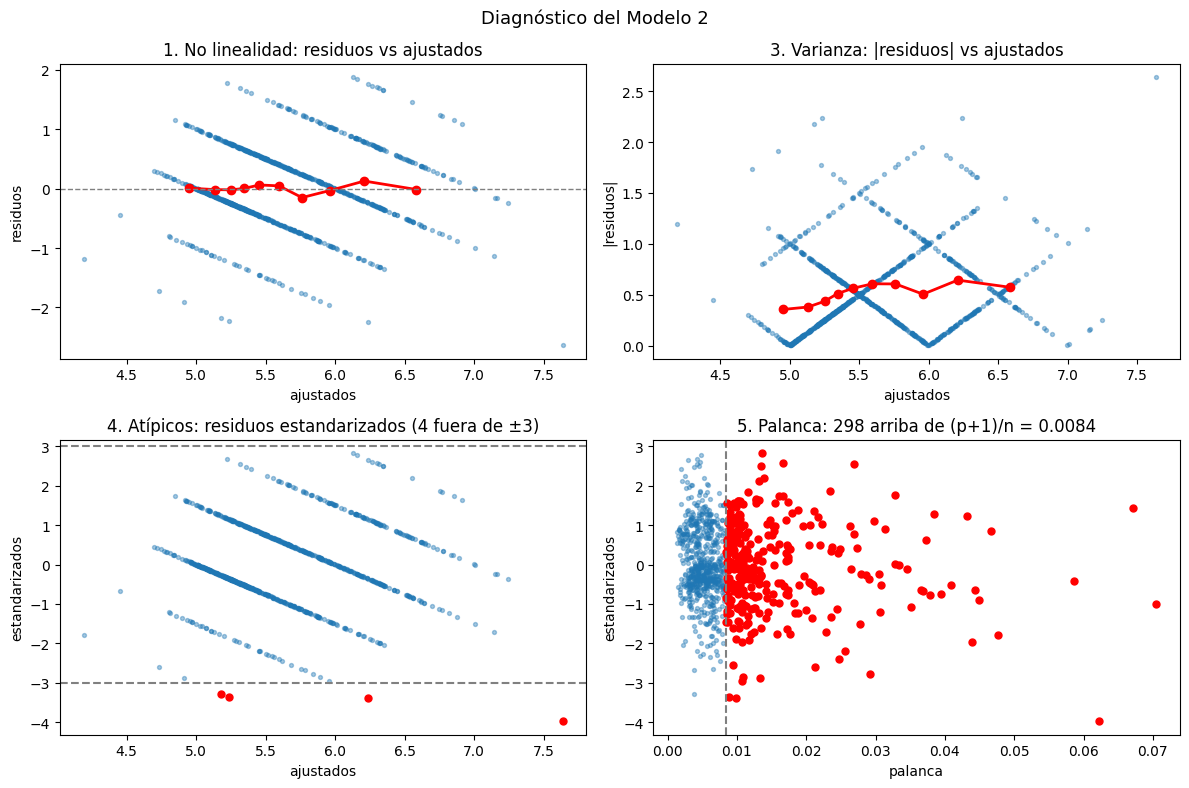

2. Correlación entre residuos consecutivos (orden del archivo): 0.0131
   Palanca máxima: 0.0705  (promedio 0.0084)
6. VIF:
chlorides               1.40
alcohol                 1.34
sulphates               1.30
volatile acidity        1.27
pH                      1.24
total sulfur dioxide    1.10
alcohol x sulphates     1.10


In [27]:
diagnostico(ols2, X_train2, y_train, "Diagnóstico del Modelo 2")

Al quitar fixed acidity y density todos los VIF quedan entre 1.1 y 1.4, ya no hay colinealidad. Lo demas se ve igual que en el modelo 1

## Ridge, Lasso y Elastic Net

In [28]:
tabla2, coefs2 = cuatro_versiones(X_train2, X_test2, y_train, y_test)

tabla2.round(4)

,R2 train,R2 test,coeficientes en 0
versión,,,
Sin penalización,0.3587,0.4157,0
Ridge,0.3587,0.4157,0
Lasso,0.3577,0.4151,0
Elastic Net,0.3584,0.4155,0


In [29]:
coefs2.round(4)

,Sin penalización,Ridge,Lasso,Elastic Net
alcohol,0.2892,0.2890,0.2861,0.2864
volatile acidity,-0.1601,-0.1601,-0.1602,-0.1600
sulphates,0.1925,0.1924,0.1797,0.1854
total sulfur dioxide,-0.0592,-0.0592,-0.0490,-0.0541
chlorides,-0.0912,-0.0911,-0.0783,-0.0845
pH,-0.0882,-0.0880,-0.0750,-0.0810
alcohol x sulphates,0.0673,0.0672,0.0571,0.0619


Aqui todos los factores aportan, asi que Lasso y Elastic Net no apagan nada y las cuatro versiones salen casi identicas

# **MODELO 3**

Polinomial con los tres factores mas fuertes, alcohol y sulphates al cuadrado

$$\text{quality} = \beta_0 + \beta_1(\text{alcohol}) + \beta_2(\text{alcohol})^2 + \beta_3(\log \text{sulphates}) + \beta_4(\log \text{sulphates})^2 + \beta_5(\text{volatile acidity})$$

In [30]:
# Se revisa qué variables tienen término cuadrático significativo por sí solas

for v in ["alcohol", "sulphates", "volatile acidity"]:
    Xp = pd.DataFrame({v: X_train_all[v], v + "^2": X_train_all[v] ** 2})
    mp = sm.OLS(y_train, sm.add_constant(Xp)).fit()
    print("%-18s p(x^2) = %.4f   R2 = %.4f" % (v, mp.pvalues.iloc[-1], mp.rsquared))

alcohol            p(x^2) = 0.0018   R2 = 0.2237
sulphates          p(x^2) = 0.0000   R2 = 0.1366
volatile acidity   p(x^2) = 0.0984   R2 = 0.1486


## Definir la matriz X para el tercer modelo

In [31]:
X_train3 = pd.DataFrame({
    "alcohol": X_train_all["alcohol"],
    "alcohol^2": X_train_all["alcohol"] ** 2,
    "sulphates": X_train_all["sulphates"],
    "sulphates^2": X_train_all["sulphates"] ** 2,
    "volatile acidity": X_train_all["volatile acidity"],
})

X_test3 = pd.DataFrame({
    "alcohol": X_test_all["alcohol"],
    "alcohol^2": X_test_all["alcohol"] ** 2,
    "sulphates": X_test_all["sulphates"],
    "sulphates^2": X_test_all["sulphates"] ** 2,
    "volatile acidity": X_test_all["volatile acidity"],
})

X_train3.head()

,alcohol,alcohol^2,sulphates,sulphates^2,volatile acidity
328,0.352420,0.124200,1.058306,1.120011,-0.670106
1043,-0.939819,0.883260,-1.007593,1.015244,-0.387402
318,-0.201397,0.040561,1.377414,1.897270,-0.387402
1208,1.552356,2.409809,0.469875,0.220782,-1.687838
83,-1.309030,1.713560,-0.835817,0.698591,0.517249


## Regresión sin penalización

In [32]:
ols3 = sm.OLS(y_train, sm.add_constant(X_train3)).fit()

print(ols3.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     100.4
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           6.28e-85
Time:                        22:15:19   Log-Likelihood:                -962.25
No. Observations:                 951   AIC:                             1936.
Df Residuals:                     945   BIC:                             1966.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.7170      0.030  

## Prueba de hipótesis

In [33]:
prueba_hipotesis(ols3)

,coeficiente,error estándar,t,p-value,significativo (α=0.05)
const,5.7170,0.0301,189.878,0.0000,sí
alcohol,0.3526,0.0279,12.625,0.0000,sí
alcohol^2,-0.0493,0.0179,-2.753,0.0060,sí
sulphates,0.1991,0.0263,7.570,0.0000,sí
sulphates^2,-0.0431,0.0124,-3.476,0.0005,sí
volatile acidity,-0.1903,0.0232,-8.187,0.0000,sí


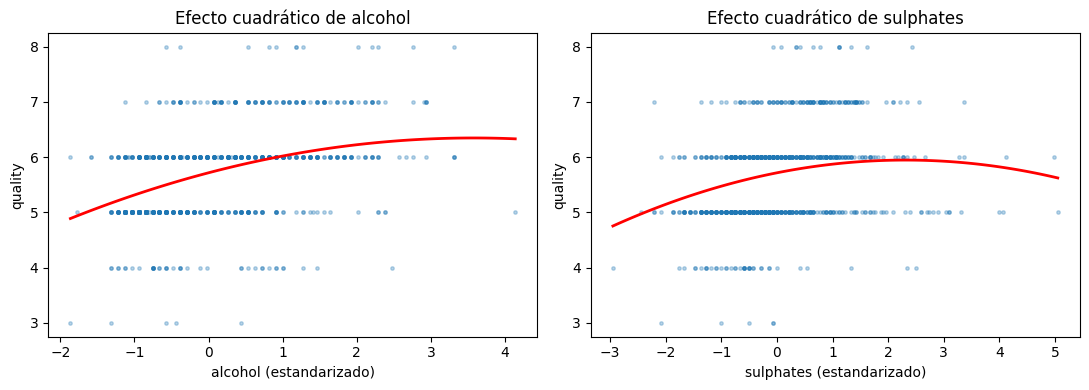

In [34]:
# Forma de la curva de cada factor cuadrático

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

for eje, v in zip(ejes, ["alcohol", "sulphates"]):
    rejilla = np.linspace(X_train_all[v].min(), X_train_all[v].max(), 100)
    curva = ols3.params["const"] + ols3.params[v] * rejilla + ols3.params[v + "^2"] * rejilla ** 2
    eje.scatter(X_train_all[v], y_train, s=6, alpha=0.3)
    eje.plot(rejilla, curva, color="red", linewidth=2)
    eje.set_xlabel(v + " (estandarizado)")
    eje.set_ylabel("quality")
    eje.set_title("Efecto cuadrático de " + v)

plt.tight_layout()
plt.show()

Los dos cuadraticos son significativos y negativos. sulphates sube la calidad hasta cierto punto y luego se aplana, en exceso dan sabor. alcohol es casi recta con una curvita hacia abajo en los mas fuertes

Con solo 5 columnas casi empata al modelo 1

## Análisis de residuos

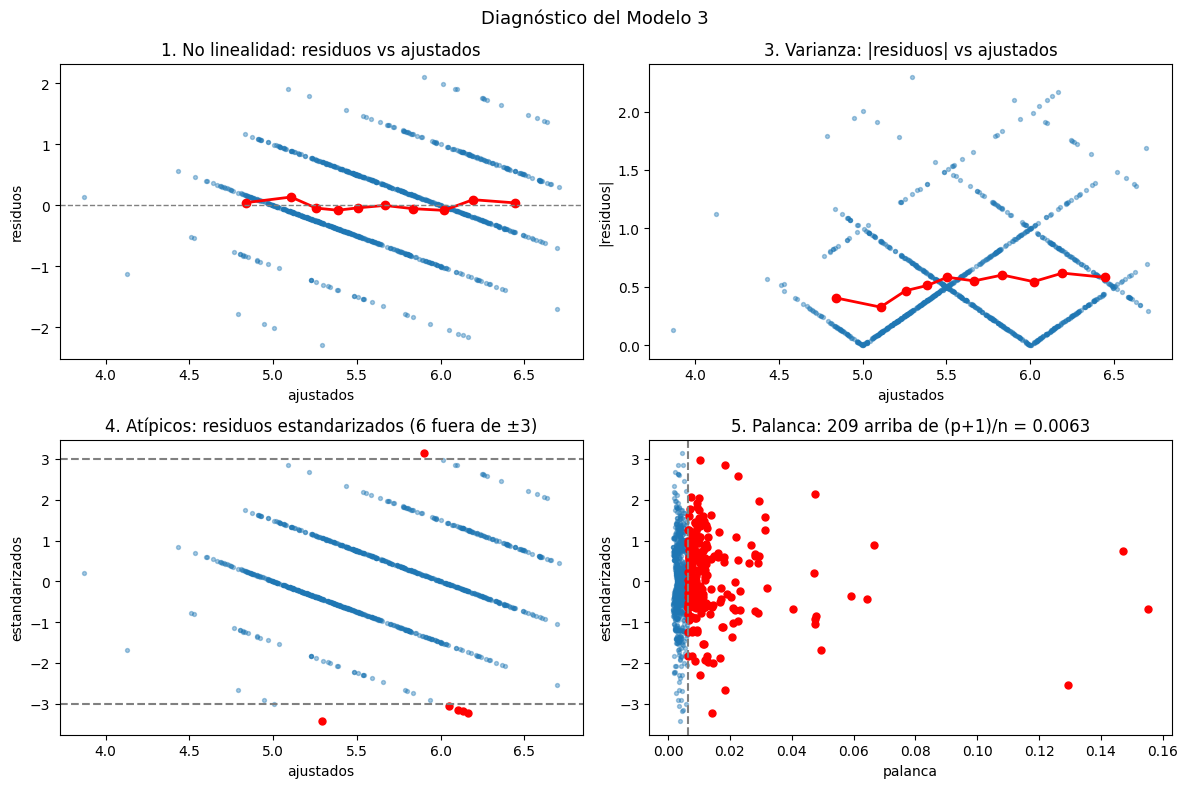

2. Correlación entre residuos consecutivos (orden del archivo): 0.0327
   Palanca máxima: 0.1553  (promedio 0.0063)
6. VIF:
alcohol             1.66
alcohol^2           1.57
sulphates           1.48
sulphates^2         1.36
volatile acidity    1.15


In [35]:
diagnostico(ols3, X_train3, y_train, "Diagnóstico del Modelo 3")

Los cuadrados suben un poco la palanca de los vinos extremos, normal en un polinomio. VIF todos abajo de 2

## Ridge, Lasso y Elastic Net

In [36]:
tabla3, coefs3 = cuatro_versiones(X_train3, X_test3, y_train, y_test)

tabla3.round(4)

,R2 train,R2 test,coeficientes en 0
versión,,,
Sin penalización,0.3468,0.4089,0
Ridge,0.3468,0.4090,0
Lasso,0.3461,0.4099,0
Elastic Net,0.3466,0.4097,0


In [37]:
coefs3.round(4)

,Sin penalización,Ridge,Lasso,Elastic Net
alcohol,0.3526,0.3520,0.3348,0.3411
alcohol^2,-0.0493,-0.0491,-0.0371,-0.0421
sulphates,0.1991,0.1990,0.1876,0.1926
sulphates^2,-0.0431,-0.0431,-0.0388,-0.0408
volatile acidity,-0.1903,-0.1902,-0.1854,-0.1875


# Ajuste de modelos y comparación de R²

Cada uno de los tres modelos se ajustó en sus cuatro versiones (doce ajustes en total) con los mismos datos de entrenamiento y los mismos alphas. Aquí se juntan los R² de entrenamiento y de prueba de las doce versiones para compararlas.

In [38]:
# Las doce versiones juntas

comparacion = pd.concat({"Modelo 1": tabla1, "Modelo 2": tabla2, "Modelo 3": tabla3}, axis=0)

comparacion.round(4)

R2 train  R2 test  coeficientes en 0
         versión                                               
Modelo 1 Sin penalización    0.3582   0.3921                  0
         Ridge               0.3582   0.3923                  0
         Lasso               0.3554   0.3982                  3
         Elastic Net         0.3570   0.3963                  2
Modelo 2 Sin penalización    0.3587   0.4157                  0
         Ridge               0.3587   0.4157                  0
         Lasso               0.3577   0.4151                  0
         Elastic Net         0.3584   0.4155                  0
Modelo 3 Sin penalización    0.3468   0.4089                  0
         Ridge               0.3468   0.4090                  0
         Lasso               0.3461   0.4099                  0
         Elastic Net         0.3466   0.4097                  0

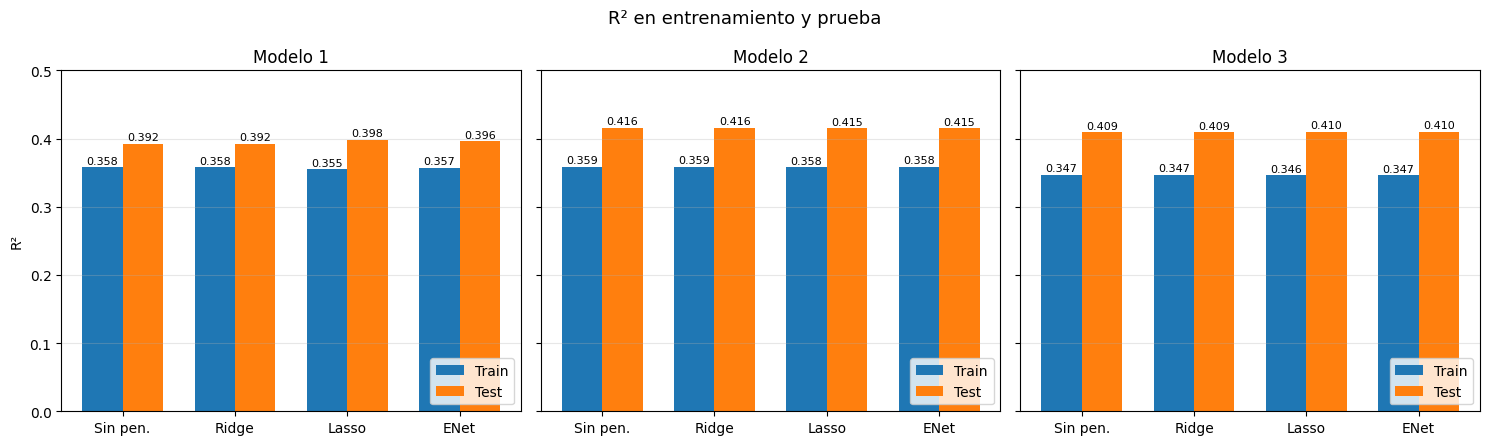

In [39]:
# R2 de train y test por modelo y versión

versiones = ["Sin penalización", "Ridge", "Lasso", "Elastic Net"]
tablas = [tabla1, tabla2, tabla3]

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
x = np.arange(len(versiones))
ancho = 0.36

for i, (eje, t) in enumerate(zip(ejes, tablas)):
    eje.bar(x - ancho / 2, t.loc[versiones, "R2 train"], ancho, label="Train")
    eje.bar(x + ancho / 2, t.loc[versiones, "R2 test"], ancho, label="Test")
    for j, v in enumerate(versiones):
        eje.text(j - ancho / 2, t.loc[v, "R2 train"] + 0.005, "%.3f" % t.loc[v, "R2 train"], ha="center", fontsize=8)
        eje.text(j + ancho / 2, t.loc[v, "R2 test"] + 0.005, "%.3f" % t.loc[v, "R2 test"], ha="center", fontsize=8)
    eje.set_title("Modelo %d" % (i + 1))
    eje.set_xticks(x)
    eje.set_xticklabels(["Sin pen.", "Ridge", "Lasso", "ENet"])
    eje.set_ylim(0, 0.5)
    eje.grid(axis="y", alpha=0.3)
    eje.legend(loc="lower right")

ejes[0].set_ylabel("R²")
plt.suptitle("R² en entrenamiento y prueba", fontsize=13)
plt.tight_layout()
plt.show()

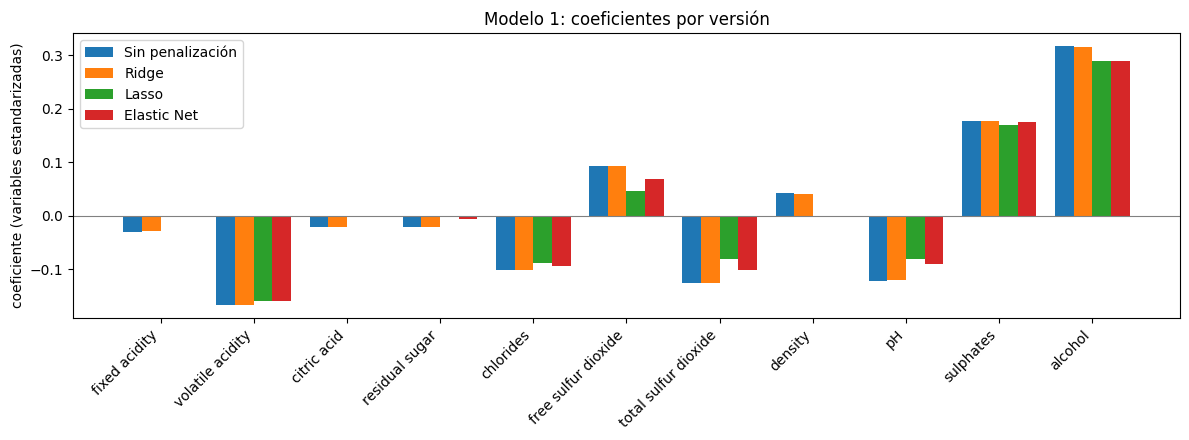

In [40]:
# Coeficientes de las tres versiones penalizadas del modelo 1, para ver qué hace cada una

fig, eje = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(coefs1))
ancho = 0.2
for k, v in enumerate(versiones):
    eje.bar(x + (k - 1.5) * ancho, coefs1[v], ancho, label=v)
eje.axhline(0, color="gray", linewidth=0.8)
eje.set_xticks(x)
eje.set_xticklabels(coefs1.index, rotation=45, ha="right")
eje.set_ylabel("coeficiente (variables estandarizadas)")
eje.set_title("Modelo 1: coeficientes por versión")
eje.legend()
plt.tight_layout()
plt.show()

Los tres modelos quedan en la misma zona, con R² de prueba entre 0.39 y 0.42. El modelo 2 es el mejor en prueba (0.4157) y el más parsimonioso: 7 columnas contra 11 del modelo 1, sin colinealidad y con todos los factores significativos. El modelo 3, con solo 5 columnas, queda casi igual (0.4089), lo que dice que casi toda la información está en `alcohol`, `sulphates` y `volatile acidity`.

En ningún modelo el R² de prueba es menor al de entrenamiento; no hay sobreajuste. De hecho el de prueba sale un poco más alto, lo que indica que la partición de prueba resultó ligeramente más fácil de predecir que la de entrenamiento.

La regularización solo ayuda en el modelo 1. Ahí Ridge deja los coeficientes casi iguales; Lasso apaga `fixed acidity`, `citric acid` y `density` (tres de los cuatro factores no significativos) y sube el R² de prueba de 0.3921 a 0.3982; Elastic Net apaga dos. En los modelos 2 y 3, que ya vienen depurados, las cuatro versiones salen prácticamente idénticas: cuando todos los factores aportan, no hay nada que penalizar.

# Análisis de significancia de factores

Para cada modelo sin penalización se hizo la prueba $H_0: \beta_j = 0$ contra $H_1: \beta_j \neq 0$ con $\alpha = 0.05$, usando el estadístico $t$ y el p-value que reporta statsmodels (las tablas de cada modelo están en su sección). Aquí se resume qué salió de las tres.

In [41]:
# Factores significativos en cada modelo sin penalización

resumen = []
for nombre, ols in [("Modelo 1", ols1), ("Modelo 2", ols2), ("Modelo 3", ols3)]:
    p = ols.pvalues.drop("const")
    resumen.append({
        "modelo": nombre,
        "factores": len(p),
        "significativos": int((p < 0.05).sum()),
        "no significativos": ", ".join(p[p >= 0.05].index) if (p >= 0.05).any() else "ninguno",
        "R2 train": round(ols.rsquared, 4),
        "F p-value": "%.2e" % ols.f_pvalue,
    })

pd.DataFrame(resumen).set_index("modelo")

,factores,significativos,no significativos,R2 train,F p-value
modelo,,,,,
Modelo 1,11,7,"fixed acidity, citric acid, residual sugar, de...",0.3582,7.85e-83
Modelo 2,7,7,ninguno,0.3587,1.26e-86
Modelo 3,5,5,ninguno,0.3468,6.28e-85


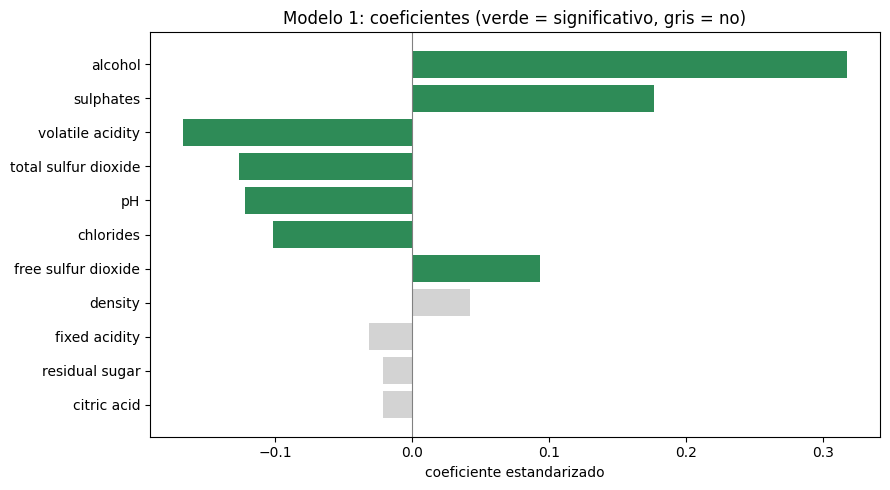

In [42]:
# Coeficientes estandarizados del modelo 1 ordenados por tamaño, con su p-value

orden = ols1.params.drop("const").abs().sort_values(ascending=False).index

fig, eje = plt.subplots(figsize=(9, 5))
colores = ["seagreen" if ols1.pvalues[f] < 0.05 else "lightgray" for f in orden]
eje.barh(range(len(orden)), ols1.params[orden], color=colores)
eje.set_yticks(range(len(orden)))
eje.set_yticklabels(orden)
eje.invert_yaxis()
eje.axvline(0, color="gray", linewidth=0.8)
eje.set_xlabel("coeficiente estandarizado")
eje.set_title("Modelo 1: coeficientes (verde = significativo, gris = no)")
plt.tight_layout()
plt.show()

**Modelo 1.** Siete factores rechazan $H_0$: `volatile acidity`, `sulphates`, `alcohol`, `total sulfur dioxide`, `chlorides`, `pH` y `free sulfur dioxide`. Los otros cuatro (`fixed acidity`, `citric acid`, `residual sugar` y `density`) no son significativos; justamente `fixed acidity` y `density` son los de VIF más alto, así que su información ya la traen otros factores. Como las variables están estandarizadas, los coeficientes se pueden comparar entre sí: los más grandes en valor absoluto son `alcohol` (0.318), `sulphates` (0.177) y `volatile acidity` (−0.167).

**Modelo 2.** Todos los factores son significativos, incluida la interacción. Su coeficiente es positivo: el alcohol sube la calidad y ese efecto se hace más grande conforme hay más sulfatos. Evaluando $\beta_1 + \beta_7 \cdot \text{sulphates}$, el efecto del alcohol vale 0.155 cuando `sulphates` está dos desviaciones abajo de la media y 0.424 cuando está dos arriba, casi el triple. Los dos factores se refuerzan, no actúan por separado.

**Modelo 3.** Los dos términos cuadráticos son significativos y negativos. `sulphates²` indica que los sulfatos suben la calidad hasta cierto punto y luego el efecto se aplana o baja, lo que tiene sentido porque en exceso dan sabor. `alcohol²` también es negativo aunque con menos significancia: la relación es casi recta con una ligera curvatura hacia abajo en los vinos más fuertes.

El estadístico F de los tres modelos tiene p-value prácticamente cero, así que los tres son significativos en conjunto. En los modelos 2 y 3, construidos solo con factores fuertes, todo es significativo incluyendo la interacción y los dos términos cuadráticos.

# Conclusiones

El objetivo general era analizar qué propiedades fisicoquímicas se asocian con la calidad del vino tinto y qué tanto se puede predecir esa calidad con regresión. Respecto a cada objetivo específico:

**Sobre el dataset (objetivo 1).** Las 1599 muestras traían 240 duplicados que se quitaron. Todas las variables eran numéricas, pero cinco tenían sesgo fuerte hacia la derecha y generaban puntos palanca; el análisis de residuos del modelo crudo fue lo que justificó transformarlas con logaritmo. Se estandarizó todo porque la regularización lo requiere.

**Sobre los modelos (objetivos 2 y 3).** Se construyeron los tres modelos pedidos en sus cuatro versiones. El modelo 2, con seis factores significativos más la interacción `alcohol × sulphates`, fue el mejor en prueba (R² = 0.4157) y el más limpio: sin colinealidad y con todos los factores significativos. El modelo 3 polinomial quedó casi igual (0.4089) con solo cinco columnas.

**Sobre los residuos (objetivo 4).** De los seis problemas, los que sí aparecieron fueron la colinealidad en el modelo 1 (`fixed acidity` y `density` con VIF mayor a 5) y los puntos palanca por las variables sesgadas. El logaritmo resolvió lo segundo y quitar esos dos factores resolvió lo primero. No hubo no linealidad marcada, ni varianza claramente no constante, ni correlación de errores; los atípicos son los vinos calificados con 3 u 8, que son muy pocos y el modelo no alcanza a distinguir.

**Sobre el R² (objetivo 5).** Los tres modelos explican entre 35 % y 42 % de la varianza de la calidad. Es moderado, pero consistente con la naturaleza del problema: la calidad es una calificación subjetiva con solo seis valores posibles y la química no captura todo lo que un catador percibe. La regularización solo ayudó en el modelo 1, donde Lasso apagó los factores inútiles; en modelos ya depurados no cambió nada.

**Sobre la significancia (objetivo 6).** Las propiedades con evidencia de afectar la calidad son el alcohol y los sulfatos (positivo) y la acidez volátil, el dióxido de azufre total, los cloruros y el pH (negativo). El efecto del alcohol depende del nivel de sulfatos, y tanto el alcohol como los sulfatos tienen un efecto con curvatura que se aplana en los valores altos.

# Referencias

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Wine Quality* [Data set]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/186/wine+quality